<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Matrix Dimensions

A1: 10 × 30
A2: 30 × 5
A3: 5 × 60
A4: 60 × 10

Minimum Scalar Multiplications = 5000

Optimal Parenthesization =
((A1 × A2) × (A3 × A4))

DP Cost Table m[i][j]

      A       1A       2A       3A       4
A1            0     1500     4500     5000
A2          ---        0     9000     4500
A3          ---      ---        0     3000
A4          ---      ---      ---        0


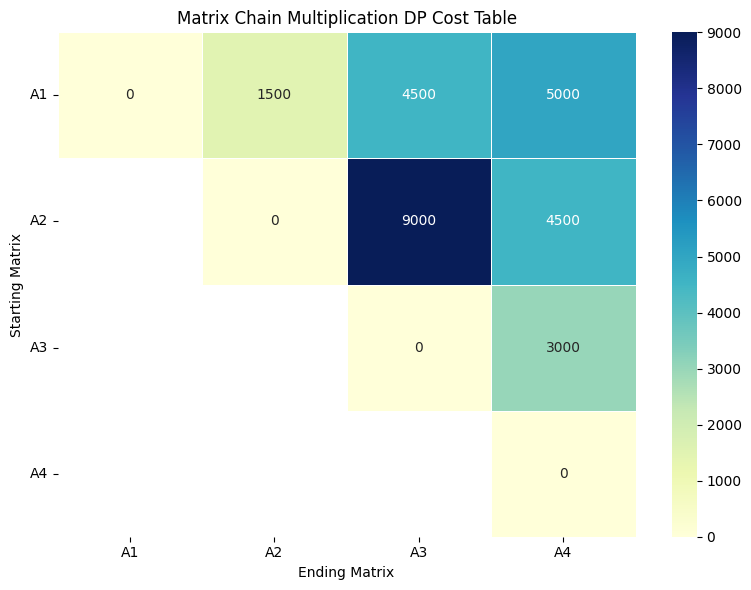

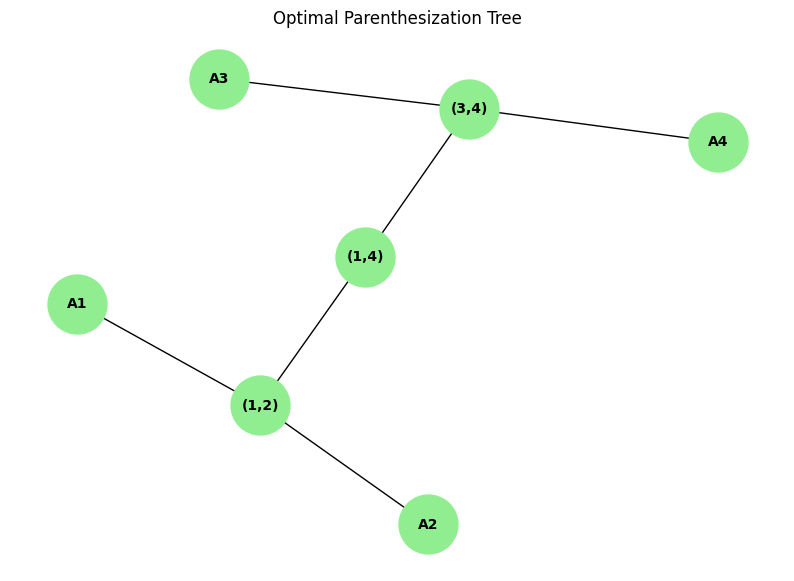

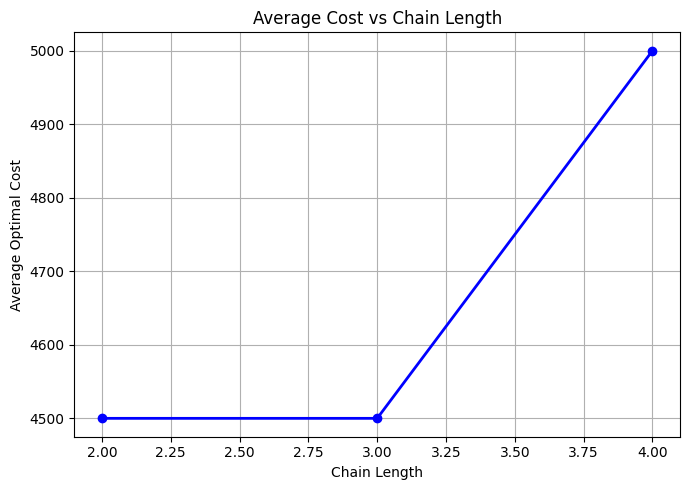

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


# -------------------------------------------------
# Matrix Chain Multiplication (Original Logic)
# -------------------------------------------------
def matrix_chain_order(dims):
    """
    Matrix Chain Multiplication using Dynamic Programming
    dims: list of dimensions
    Matrix Ai has dimensions dims[i-1] x dims[i]

    Time Complexity : O(n^3)
    Space Complexity: O(n^2)
    """

    n = len(dims) - 1

    # DP table
    m = [[0] * (n + 1) for _ in range(n + 1)]

    # Split table
    s = [[0] * (n + 1) for _ in range(n + 1)]

    # l = chain length
    for l in range(2, n + 1):

        for i in range(1, n - l + 2):

            j = i + l - 1

            m[i][j] = float('inf')

            for k in range(i, j):

                cost = (
                    m[i][k]
                    + m[k + 1][j]
                    + dims[i - 1] * dims[k] * dims[j]
                )

                if cost < m[i][j]:
                    m[i][j] = cost
                    s[i][j] = k

    return m, s


# -------------------------------------------------
# Print Optimal Parenthesization
# -------------------------------------------------
def print_optimal_parens(s, i, j):

    if i == j:
        return f"A{i}"

    k = s[i][j]

    left = print_optimal_parens(s, i, k)
    right = print_optimal_parens(s, k + 1, j)

    return f"({left} × {right})"


# -------------------------------------------------
# Print DP Table
# -------------------------------------------------
def print_dp_table(m, n):

    print("\nDP Cost Table m[i][j]\n")

    print(f'{"":>6}', end='')

    for j in range(1, n + 1):
        print(f"A{j:>8}", end='')

    print()

    for i in range(1, n + 1):

        print(f"A{i:<5}", end='')

        for j in range(1, n + 1):

            if j < i:
                print(f'{"---":>9}', end='')
            else:
                print(f'{m[i][j]:>9}', end='')

        print()


# -------------------------------------------------
# Heatmap of DP Table
# -------------------------------------------------
def plot_dp_heatmap(m, n):

    data = []

    for i in range(1, n + 1):

        row = []

        for j in range(1, n + 1):

            if j < i:
                row.append(np.nan)
            else:
                row.append(m[i][j])

        data.append(row)

    data = np.array(data, dtype=float)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        data,
        annot=True,
        fmt=".0f",
        cmap="YlGnBu",
        linewidths=0.5,
        mask=np.isnan(data),
        cbar=True
    )

    plt.title("Matrix Chain Multiplication DP Cost Table")

    plt.xlabel("Ending Matrix")
    plt.ylabel("Starting Matrix")

    plt.xticks(
        np.arange(n) + 0.5,
        [f"A{i}" for i in range(1, n + 1)]
    )

    plt.yticks(
        np.arange(n) + 0.5,
        [f"A{i}" for i in range(1, n + 1)],
        rotation=0
    )

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Build Parenthesization Tree
# -------------------------------------------------
def build_tree(G, s, i, j, parent=None):

    if i == j:

        node = f"A{i}"

        G.add_node(node)

        if parent is not None:
            G.add_edge(parent, node)

        return

    node = f"({i},{j})"

    G.add_node(node)

    if parent is not None:
        G.add_edge(parent, node)

    k = s[i][j]

    build_tree(G, s, i, k, node)
    build_tree(G, s, k + 1, j, node)


# -------------------------------------------------
# Draw Parenthesization Tree
# -------------------------------------------------
def draw_tree(s, n):

    G = nx.DiGraph()

    build_tree(G, s, 1, n)

    pos = nx.spring_layout(G, seed=20)

    plt.figure(figsize=(10, 7))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1800,
        node_color="lightgreen"
    )

    nx.draw_networkx_edges(G, pos)

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold"
    )

    plt.title("Optimal Parenthesization Tree")
    plt.axis("off")
    plt.show()


# -------------------------------------------------
# Plot Cost vs Chain Length
# -------------------------------------------------
def plot_chain_costs(m, n):

    lengths = []
    avg_costs = []

    for l in range(2, n + 1):

        values = []

        for i in range(1, n - l + 2):

            j = i + l - 1

            values.append(m[i][j])

        lengths.append(l)
        avg_costs.append(sum(values) / len(values))

    plt.figure(figsize=(7, 5))

    plt.plot(
        lengths,
        avg_costs,
        marker="o",
        linewidth=2,
        color="blue"
    )

    plt.grid(True)

    plt.xlabel("Chain Length")
    plt.ylabel("Average Optimal Cost")
    plt.title("Average Cost vs Chain Length")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# MAIN PROGRAM
# -------------------------------------------------
if __name__ == "__main__":

    # Example:
    # A1 = 10x30
    # A2 = 30x5
    # A3 = 5x60
    # A4 = 60x10

    dims = [10, 30, 5, 60, 10]

    n = len(dims) - 1

    print("\nMatrix Dimensions\n")

    for i in range(n):
        print(f"A{i+1}: {dims[i]} × {dims[i+1]}")

    m, s = matrix_chain_order(dims)

    print("\nMinimum Scalar Multiplications =", m[1][n])

    print("\nOptimal Parenthesization =")

    print(print_optimal_parens(s, 1, n))

    print_dp_table(m, n)

    # Graphs
    plot_dp_heatmap(m, n)
    draw_tree(s, n)
    plot_chain_costs(m, n)